In [1]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix



In [ ]:
df = pd.read_csv('Final.csv')

target_col = 'mental_health_risk'

categorical_cols = df.select_dtypes(include=['object']).columns.tolist()


In [3]:
le_target = LabelEncoder()
df[target_col] = le_target.fit_transform(df[target_col].astype(str))
target_names = [str(c) for c in le_target.classes_]

encoders = {}

for col in categorical_cols:
    if col != target_col:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))
        encoders[col] = le

df = df.fillna(df.median(numeric_only=True))


In [4]:
X = df.drop(target_col, axis=1)
y = df[target_col]

feature_columns = X.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [5]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

base_learner = DecisionTreeClassifier(max_depth=3, class_weight='balanced')

ada_model = AdaBoostClassifier(
    estimator=base_learner,   
    n_estimators=200,
    learning_rate=0.01,
    random_state=42
)

ada_model.fit(X_train, y_train)


AdaBoostClassifier(estimator=DecisionTreeClassifier(class_weight='balanced',
                                                    max_depth=3),
                   learning_rate=0.01, n_estimators=200, random_state=42)

In [6]:
y_pred = ada_model.predict(X_test)

print("--- FINAL MODEL PERFORMANCE ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred) * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=target_names))


--- FINAL MODEL PERFORMANCE ---
Accuracy Score: 82.18%

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.99      0.96      1871
           1       0.75      0.95      0.83      2365
           2       1.00      0.03      0.06       764

    accuracy                           0.82      5000
   macro avg       0.89      0.65      0.62      5000
weighted avg       0.86      0.82      0.76      5000



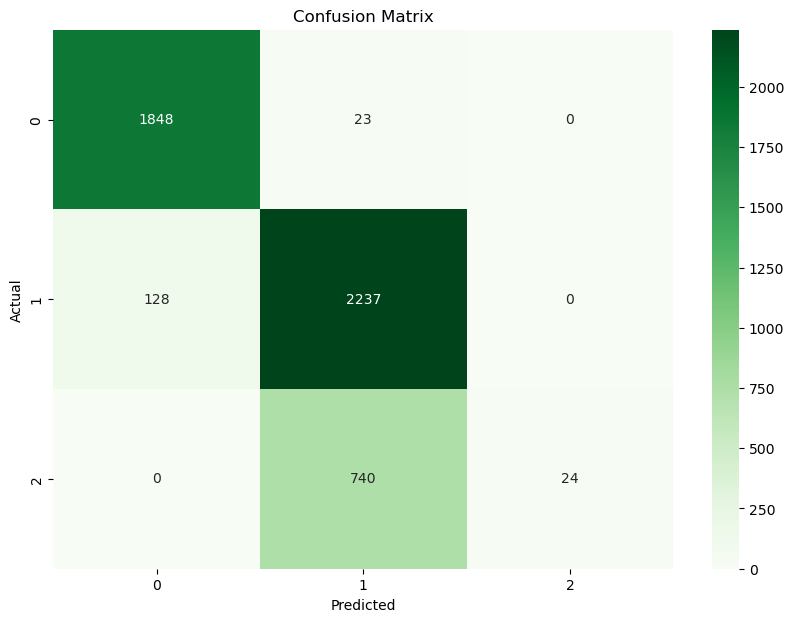

In [8]:
plt.figure(figsize=(10, 7))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('confusion_matrix.png')
plt.show()




In [9]:
model_data = {
    'model': ada_model,
    'scaler': scaler,
    'le_target': le_target,
    'encoders': encoders,              
    'feature_columns': feature_columns 
}

with open('mental_health_adaboost_model.pkl', 'wb') as f:
    pickle.dump(model_data, f)

print("\n✅ Success: Model, Scaler, Encoders saved!")


✅ Success: Model, Scaler, Encoders saved!


In [11]:
import pandas as pd
import os

# 1. LOAD DATASET
df = pd.read_csv('Final.csv')

# 2. DROP TARGET COLUMN
target_col = 'mental_health_risk'
df = df.drop(columns=[target_col])

# 3. CREATE OUTPUT FOLDER
output_folder = "row_data"
os.makedirs(output_folder, exist_ok=True)

# 4. SAVE EACH ROW AS A SEPARATE CSV
for i, row in df.iterrows():
    row_df = pd.DataFrame([row])
    
    file_path = os.path.join(output_folder, f"row_{i+1}.csv")
    row_df.to_csv(file_path, index=False)

print(f"✅ Done! {len(df)} row files created in '{output_folder}' folder.")

✅ Done! 20501 row files created in 'row_data' folder.


In [18]:
import pandas as pd
import pickle

file_path = "row_data/row_6583.csv"

# 1. LOAD MODEL
with open('mental_health_adaboost_model.pkl', 'rb') as f:
    model_data = pickle.load(f)

model = model_data['model']
scaler = model_data['scaler']
le_target = model_data['le_target']
encoders = model_data['encoders']
feature_columns = model_data['feature_columns']

# 2. LOAD INPUT DATA
df = pd.read_csv(file_path)

# 3. APPLY ENCODING (handle unknown values safely)
for col, le in encoders.items():
    if col in df.columns:
        df[col] = df[col].map(lambda x: le.transform([x])[0] if x in le.classes_ else -1)

# 4. ENSURE COLUMN ORDER + HANDLE MISSING COLUMNS
for col in feature_columns:
    if col not in df.columns:
        df[col] = 0  # default value if missing

df = df[feature_columns]

# 5. SCALE
X_scaled = scaler.transform(df)

# 6. PREDICT
prediction = model.predict(X_scaled)

predicted_label = le_target.inverse_transform(prediction)

# 8. OUTPUT
print("===================================")
print("Input File:", file_path)
print("Predicted Mental Health Risk:", predicted_label[0])
print("===================================")

Input File: row_data/row_6583.csv
Predicted Mental Health Risk: 0
